In [ ]:

# Install required libraries (if not installed)
!pip install tensorflow pandas scikit-learn seaborn matplotlib

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:

from google.colab import files

# This will trigger a button for you to select your JSON file
uploaded = files.upload()

# Confirm that the file is loaded
if uploaded:
    file_name = list(uploaded.keys())[0]
    print(f"Successfully uploaded: {file_name}")
else:
    print("No file was uploaded.")

Saving test_features.csv to test_features.csv
Successfully uploaded: test_features.csv


In [ ]:

import json
import pandas as pd
import os

file_name = list(uploaded.keys())[0]
file_ext = os.path.splitext(file_name)[1].lower()

print(f"Detected file type: {file_ext}")

if file_ext == '.csv':
    df = pd.read_csv(file_name)
    print("CSV loaded successfully.")

elif file_ext == '.json':
    with open(file_name, "r") as f:
        data = json.load(f)

    if isinstance(data, list):
        df = pd.json_normalize(data)
    elif isinstance(data, dict):
        list_key = [k for k, v in data.items() if isinstance(v, list)]
        if list_key:
            df = pd.json_normalize(data, record_path=[list_key[0]])
        else:
            df = pd.json_normalize(data)

    print("JSON loaded successfully.")

else:
    raise ValueError("Unsupported file format")

print("Dataset shape:", df.shape)
df.head()

Detected file type: .csv
CSV loaded successfully.
Dataset shape: (624, 31)


,mean,std,min,max,median,p10,p90,skewness,kurtosis,entropy,...,lbp_1,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,lbp_7,lbp_8,lbp_9,image
0,0.401953,0.245209,0.0,1.0,0.447059,0.000000,0.694118,-0.394638,-1.111246,7.021966,...,0.066666,0.052521,0.083130,0.130203,0.099854,0.060211,0.070557,0.232590,0.133865,NORMAL2-IM-0336-0001.jpeg
1,0.395549,0.243017,0.0,1.0,0.407843,0.011765,0.709804,-0.100981,-1.114263,7.444343,...,0.067673,0.058578,0.098709,0.161713,0.123627,0.066589,0.068619,0.170319,0.122421,IM-0101-0001.jpeg
2,0.422183,0.287244,0.0,1.0,0.447059,0.000000,0.788235,-0.149753,-1.278479,6.995603,...,0.060623,0.046539,0.087357,0.150879,0.115723,0.056534,0.060074,0.256378,0.110077,NORMAL2-IM-0337-0001.jpeg
3,0.630344,0.210813,0.0,1.0,0.678431,0.352941,0.862745,-1.036530,0.853875,7.449801,...,0.082932,0.054703,0.093109,0.140472,0.112473,0.068314,0.081802,0.122864,0.160889,NORMAL2-IM-0198-0001.jpeg
4,0.533302,0.219797,0.0,1.0,0.545098,0.250980,0.800000,-0.571811,-0.048995,7.581055,...,0.085510,0.058563,0.087143,0.127747,0.103348,0.071960,0.088699,0.111603,0.172272,IM-0013-0001.jpeg


In [ ]:

def get_label(img_name):
    if "NORMAL" in img_name.upper():
        return 0
    else:
        return 1

df["label"] = df["image"].apply(get_label)

target_column = "label"

X = df.drop(columns=[target_column, "image"])
y = df[target_column]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing done:", X_train.shape)

Preprocessing done: (499, 30)


In [ ]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

model.fit(X_train, y_train, epochs=50, batch_size=8)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6874 - loss: 0.5307
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7836 - loss: 0.4179
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8257 - loss: 0.3906
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8417 - loss: 0.3582
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8377 - loss: 0.3438
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8517 - loss: 0.3335
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8477 - loss: 0.3236
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8758 - loss: 0.3032
Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8778 - loss: 0.3004
Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.2899
Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8818 - loss: 0.2847
Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8737 - lo

In [ ]:

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


Accuracy: 0.864

Confusion Matrix:
 [[25 13]
 [ 4 83]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.66      0.75        38
           1       0.86      0.95      0.91        87

    accuracy                           0.86       125
   macro avg       0.86      0.81      0.83       125
weighted avg       0.86      0.86      0.86       125



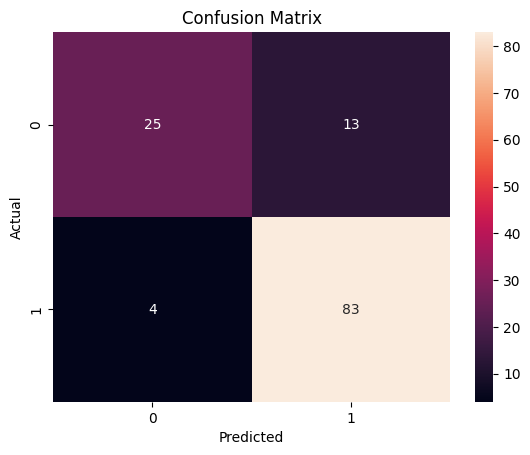

In [ ]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()